这一部分是画不同温度区间的DEM图像

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from skimage.transform import resize

In [2]:
time_list=glob.glob(os.path.join(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\','*.fits'))
file_list=glob.glob(os.path.join(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM_bin\\','*.sav'))

In [3]:
from scipy.io import readsav

# 读取 IDL 保存的 .sav 文件
data = readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131.sav', python_dict=True)

# 提取保存的结构
matrix_struct = data['matrix_struct']

# 遍历结构，提取每个矩阵
matrices = []
for i, entry in enumerate(matrix_struct):
    matrix = entry['matrix'].astype(float)  # 提取矩阵并转换为 NumPy 数组
    matrices.append(matrix)
    #print(f"Matrix {i}: Shape {matrix.shape}")

In [4]:
datas=readsav(file_list[0])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
smap_temp_1=result['SMAP_TEMP_1'][0]
smap_em_1=result['SMAP_EM_1'][0]
smap_temp_16=result['SMAP_TEMP_16'][0]
smap_em_16=result['SMAP_EM_16'][0]
smap_temp_2=result['SMAP_TEMP_2'][0]
smap_em_2=result['SMAP_EM_2'][0]
smap_temp_4=result['SMAP_TEMP_4'][0]
smap_em_4=result['SMAP_EM_4'][0]
smap_temp_8=result['SMAP_TEMP_8'][0]
smap_em_8=result['SMAP_EM_8'][0]

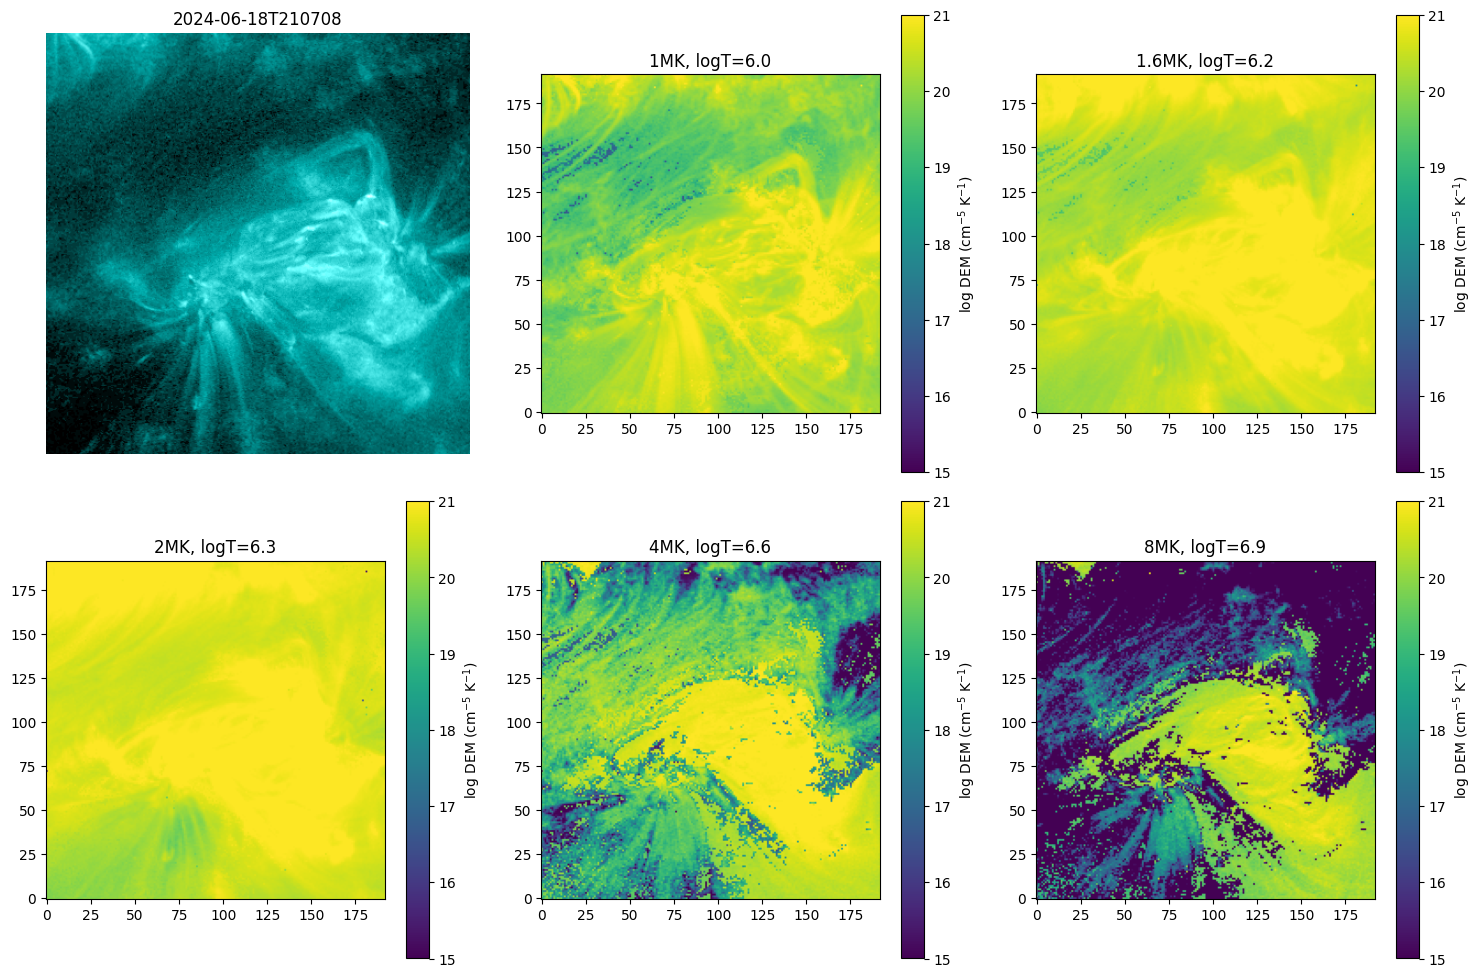

In [12]:
fig = plt.figure(figsize=(15, 10))
dem_title = 'log DEM (cm$^{-5}$ K$^{-1}$)'

# 第一个子图 - 没有colorbar
plt.subplot(2, 3, 1)
plt.imshow(np.log1p(matrices[i]), cmap='sdoaia131', origin='lower', vmin=0.5, vmax=6)
plt.axis('off')
plt.title(time_list[i+32][-38:-21])

# 温度对应的子图配置
temp_configs = [
    (5, '1MK, logT=6.0'),
    (7, '1.6MK, logT=6.2'),
    (8, '2MK, logT=6.3'),
    (11, '4MK, logT=6.6'),
    (14, '8MK, logT=6.9')
]

# 创建后面的5个子图
for idx, (temp_idx, title_text) in enumerate(temp_configs, start=2):
    plt.subplot(2, 3, idx)
    im = plt.imshow(np.log10(dem_out[temp_idx, :, :]), origin='lower',vmin=15,vmax=21)
    cbar = plt.colorbar()
    cbar.set_label(dem_title, fontsize=10)
    plt.title(title_text)

plt.tight_layout()
plt.show()

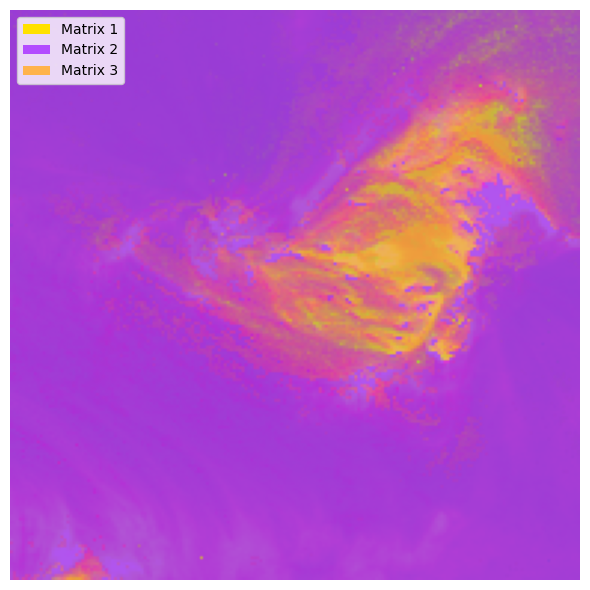

In [20]:
matrix_list=[dem_out[8,:,:],dem_out[11,:,:],dem_out[13,:,:],dem_out[14,:,:],dem_out[15,:,:]]
labels = ['Temperature 1', 'Temperature 2', 'Temperature 3', 'Temperature 4', 'Temperature 5']
if len(matrix_list) != 5:
    raise ValueError("需要5个矩阵")

matrix_labels = [f'Matrix {i+1}' for i in range(5)]

alphas = [0.6, 0.6, 0.6, 0.6, 0.6]  # 所有层都设置相同透明度便于观看

# 真实存在的matplotlib colormap
#colormaps = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges']
colormaps = ['hot', 'cool', 'spring', 'summer', 'autumn']
fig, ax = plt.subplots(figsize=(6,6))
k=3
# 第一层：黑色背景
ax.imshow(np.zeros_like(matrix_list[0]), cmap='gray', vmin=0, vmax=1)

# 逐层叠加
for i, (matrix, label, cmap, alpha) in enumerate(zip(matrix_list[:k], matrix_labels[:k], colormaps[:k], alphas[:k])):
    # 归一化矩阵到 [0, 1]
    vmin = np.percentile(matrix, 2)
    vmax = np.percentile(matrix, 98)
    normalized = np.clip((matrix - vmin) / (vmax - vmin), 0, 1)
    
    # 叠加此层
    ax.imshow(normalized, cmap=cmap, alpha=alpha, vmin=0, vmax=1)

#ax.set_title('5个矩阵叠加显示', fontsize=14, fontweight='bold')
ax.axis('off')

# 添加图例
from matplotlib.patches import Patch
legend_elements = []
for label, cmap in zip(matrix_labels[:k], colormaps[:k]):
    color_map = plt.get_cmap(cmap)
    color = color_map(0.7)
    legend_elements.append(Patch(facecolor=color, label=label))

ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
for i in range(0,101,2):
    datas=readsav(file_list[i])
    result=datas['result']
    dem_out=result['DEM_OUT'][0]
    # 选择3个矩阵用于RGB合成
    matrix_list = [dem_out[8,:,:], dem_out[11,:,:], dem_out[14,:,:]]  # 3个不同温度
    #matrix_labels = ['4MK', '4MK', '8MK']

    # 检查
    if len(matrix_list) != 3:
        raise ValueError("RGB合成需要3个矩阵")

    # 归一化每个矩阵到 [0, 1]
    rgb_channels = []
    for matrix in matrix_list:
        vmin = np.percentile(matrix, 1)
        vmax = np.percentile(matrix, 99)
        normalized = np.clip((matrix - vmin) / (vmax - vmin), 0, 1)
        rgb_channels.append(normalized)

    # 堆叠成RGB图像
    rgb_composite = np.stack(rgb_channels, axis=2)

    # 可选：应用伽玛校正增强对比
    rgb_composite = rgb_composite ** 0.7

    fig, ax1 = plt.subplots(1, 1, figsize=(7, 6))

    # 左图：RGB合成
    ax1.imshow(rgb_composite,origin='lower')
    # ax1.set_title(f'RGB合成 (R:{matrix_labels[0]}, G:{matrix_labels[1]}, B:{matrix_labels[2]})', 
    #               fontsize=12, fontweight='bold')
    ax1.axis('off')
    ax1.set_title('Red:2MK Green:4MK Blue:8MK')

    plt.tight_layout()
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM RGB\\'+str(i+32).zfill(3)+'.png',dpi=300)
    plt.close()

Text(0.5, 1.0, '8MK, logT=6.9')

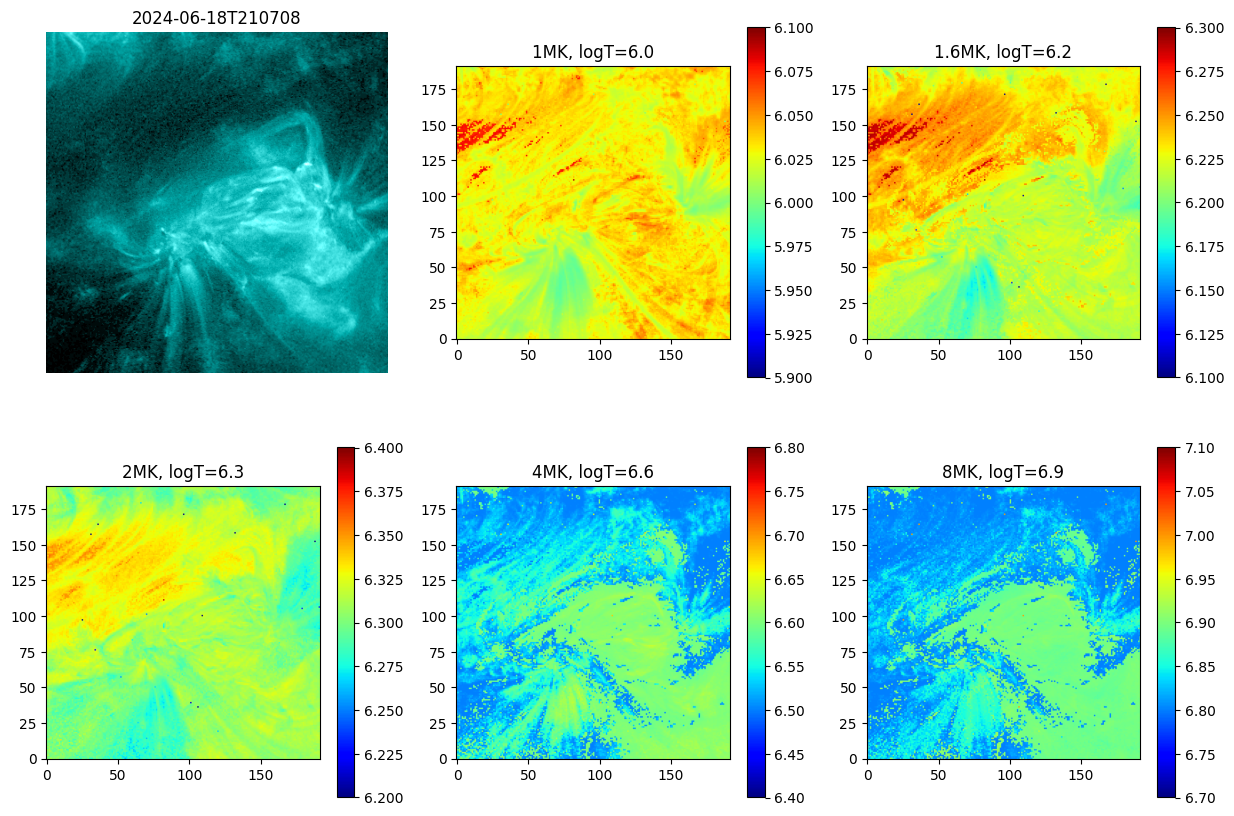

In [27]:
i=0
fig=plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.imshow(np.log1p(matrices[i]), cmap='sdoaia131', origin='lower',vmin=0.5,vmax=6)
plt.axis('off')
plt.title(time_list[i+32][-38:-21])

plt.subplot(2,3,2)
plt.imshow(np.log10(smap_temp_1),cmap='jet',origin='lower',vmin=5.9,vmax=6.1)
plt.colorbar()
plt.title('1MK, logT=6.0')

plt.subplot(2,3,3)
plt.imshow(np.log10(smap_temp_16),cmap='jet',origin='lower',vmin=6.1,vmax=6.3)
plt.colorbar()
plt.title('1.6MK, logT=6.2')

plt.subplot(2,3,4)
plt.imshow(np.log10(smap_temp_2),cmap='jet',origin='lower',vmin=6.2,vmax=6.4)
plt.colorbar()
plt.title('2MK, logT=6.3')

plt.subplot(2,3,5)
plt.imshow(np.log10(smap_temp_4),cmap='jet',origin='lower',vmin=6.4,vmax=6.8)
plt.colorbar()
plt.title('4MK, logT=6.6')

plt.subplot(2,3,6)
plt.imshow(np.log10(smap_temp_8),cmap='jet',origin='lower',vmin=6.7,vmax=7.1)
plt.colorbar()
plt.title('8MK, logT=6.9')

In [12]:
for i in range(0,101,2):
    datas=readsav(file_list[i])
    result=datas['result']
    dem_out=result['DEM_OUT'][0]
    fig = plt.figure(figsize=(15, 10))
    dem_title = 'log DEM (cm$^{-5}$ K$^{-1}$)'
    # 第一个子图 - 没有colorbar
    plt.subplot(2, 3, 1)
    plt.imshow(np.log1p(matrices[i]), cmap='sdoaia131', origin='lower', vmin=0.5, vmax=6)
    plt.axis('off')
    plt.title(time_list[i+32][-38:-21])

    # 温度对应的子图配置
    temp_configs = [
        (5, '1MK, logT=6.0'),
        (7, '1.6MK, logT=6.2'),
        (8, '2MK, logT=6.3'),
        (11, '4MK, logT=6.6'),
        (14, '8MK, logT=6.9')
    ]

    # 创建后面的5个子图
    for idx, (temp_idx, title_text) in enumerate(temp_configs, start=2):
        plt.subplot(2, 3, idx)
        im = plt.imshow(np.log10(dem_out[temp_idx, :, :]), origin='lower',vmin=15,vmax=21)
        cbar = plt.colorbar()
        cbar.set_label(dem_title, fontsize=10)
        plt.title(title_text)

    plt.tight_layout()
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM_fig\\'+str(i+32).zfill(3)+'.jpg',dpi=300)
    plt.close()
